# 05 — Pipeline Test
End-to-end sanity checks for the Netflix CTR Optimization POC.

**What this notebook checks:**
1. Model loads and serializes correctly
2. Model produces reasonable CTR predictions on test inputs
3. Personalization pipeline outputs look correct (~8800 rows, 3 segments)
4. Genre-level CTR patterns match expected findings (Thriller gap, Documentary stability)
5. No data quality issues (NaNs, out-of-range values, collapsed predictions)

Run all cells top to bottom. Each section prints PASS or FAIL with details.

## 0. Setup

In [14]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ----------------------------------------------------------------
# UPDATE THESE PATHS if your folder structure is different
# ----------------------------------------------------------------
REPO_ROOT      = os.path.dirname(os.getcwd())
OUTPUTS_DIR    = os.path.join(REPO_ROOT, 'outputs')
FIGURES_DIR   = os.path.join(REPO_ROOT, 'figures')
MODEL_PATH     = os.path.join(REPO_ROOT, 'models/xgb_ctr_model.pkl')
PIPELINE_PATH  = os.path.join(REPO_ROOT, 'outputs/netflix_ctr_predictions.csv')
# ----------------------------------------------------------------

def check(label, condition, detail=''):
    status = '✅ PASS' if condition else '❌ FAIL'
    print(f"{status}  {label}")
    if detail:
        print(f"       {detail}")
    return condition

print('Setup complete.')

Setup complete.


## 1. Model Load Test
Checks that the serialized model file exists and loads without errors.

In [2]:
print('=== 1. MODEL LOAD ===')

# Check file exists
check('Model file exists', os.path.exists(MODEL_PATH), MODEL_PATH)

# Load it
try:
    model = joblib.load(MODEL_PATH)
    check('Model loads without error', True)
except Exception as e:
    check('Model loads without error', False, str(e))
    raise

# Basic model sanity
check('Model has predict_proba', hasattr(model, 'predict_proba'))
check('Model is XGBoost', 'XGB' in type(model).__name__ or 'xgb' in str(type(model)).lower(),
      f'Actual type: {type(model).__name__}')

print(f"\nModel type: {type(model).__name__}")
print(f"Number of features expected: {model.n_features_in_}")

=== 1. MODEL LOAD ===
✅ PASS  Model file exists
       /Users/animisha/Documents/ml-netflix-artwork-optimization-poc/models/xgb_ctr_model.pkl
✅ PASS  Model loads without error
✅ PASS  Model has predict_proba
✅ PASS  Model is XGBoost
       Actual type: XGBClassifier

Model type: XGBClassifier
Number of features expected: 12


## 2. Single Prediction Test
Feeds a hand-crafted input row and checks the output is a valid probability.

> **Note:** Update `FEATURE_NAMES` and values below to match the exact columns your model was trained on (check notebook 01/02).

In [3]:
print('=== 2. SINGLE PREDICTION ===')

# ----------------------------------------------------------------
# UPDATE: replace with your actual feature names and typical values
# Run model.feature_names_in_ if unsure
# ----------------------------------------------------------------
try:
    feature_names = list(model.feature_names_in_)
    print(f"Features model expects: {feature_names}")
except AttributeError:
    print("Could not auto-detect feature names — set them manually below")
    feature_names = [
    'product', 'campaign_id', 'webpage_id', 'product_category_1',
    'user_group_id', 'gender', 'age_level', 'user_depth',
    'city_development_index', 'var_1',
    'age_depth',   # age_level * user_depth
    'city_var'     # city_development_index * var_1
    ]

# Build a test row using median-ish values — just needs to be valid
test_row = {feat: 0 for feat in feature_names}   # start with zeros
test_df = pd.DataFrame([test_row])

try:
    pred_prob = model.predict_proba(test_df)[0][1]
    check('predict_proba runs on valid input', True)
    check('Output is a valid probability (0–1)', 0.0 <= pred_prob <= 1.0,
          f'Predicted CTR: {pred_prob:.4f}')
    print(f"\nPredicted CTR on zero-filled row: {pred_prob:.4f}")
except Exception as e:
    check('predict_proba runs on valid input', False, str(e))
    raise

=== 2. SINGLE PREDICTION ===
Features model expects: [np.str_('product'), np.str_('campaign_id'), np.str_('webpage_id'), np.str_('product_category_1'), np.str_('user_group_id'), np.str_('gender'), np.str_('age_level'), np.str_('user_depth'), np.str_('city_development_index'), np.str_('var_1'), np.str_('age_depth'), np.str_('city_var')]
✅ PASS  predict_proba runs on valid input
✅ PASS  Output is a valid probability (0–1)
       Predicted CTR: 0.2375

Predicted CTR on zero-filled row: 0.2375


## 3. Pipeline Output Test
Loads the full personalization output CSV and checks shape, completeness, and value ranges.

In [4]:
print('=== 3. PIPELINE OUTPUT LOAD ===')

check('Pipeline output file exists', os.path.exists(PIPELINE_PATH), PIPELINE_PATH)

try:
    df = pd.read_csv(PIPELINE_PATH)
    check('Output CSV loads without error', True)
except Exception as e:
    check('Output CSV loads without error', False, str(e))
    raise

print(f"\nShape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
display(df.head())

=== 3. PIPELINE OUTPUT LOAD ===
✅ PASS  Pipeline output file exists
       /Users/animisha/Documents/ml-netflix-artwork-optimization-poc/outputs/netflix_ctr_predictions.csv
✅ PASS  Output CSV loads without error

Shape: (26421, 7)
Columns: ['show_id', 'title', 'genre_bucket', 'user_segment', 'avg_aesthetic_score', 'high_quality_rate', 'predicted_ctr']

First 5 rows:


,show_id,title,genre_bucket,user_segment,avg_aesthetic_score,high_quality_rate,predicted_ctr
0,s1,Dick Johnson Is Dead,Documentaries,drama_viewer,5.408,0.723,0.4458
1,s1,Dick Johnson Is Dead,Documentaries,action_viewer,5.408,0.723,0.4576
2,s1,Dick Johnson Is Dead,Documentaries,family_viewer,5.408,0.723,0.4315
3,s2,Blood & Water,International Movies,drama_viewer,5.472,0.778,0.2642
4,s2,Blood & Water,International Movies,action_viewer,5.472,0.778,0.1406


In [5]:
print('=== 3a. SHAPE & COMPLETENESS ===')

# Expected: ~8800 titles × 3 segments = ~26400 rows (long format)
# OR: ~8800 rows × columns for title, genre, ctr_action, ctr_drama, ctr_family (wide format)
# Adjust these checks based on your actual format

n_rows, n_cols = df.shape

# Wide format check (one row per title)
if n_rows > 5000 and n_rows < 15000:
    check('Row count looks right (~8800 titles)', 7000 <= n_rows <= 10000,
          f'Got {n_rows} rows')
# Long format check (one row per title × segment)
elif n_rows > 15000:
    check('Row count looks right (~26400 title×segment combos)', 20000 <= n_rows <= 35000,
          f'Got {n_rows} rows')
else:
    check('Row count looks reasonable', False, f'Only {n_rows} rows — pipeline may not have run fully')

# No nulls in key columns
null_counts = df.isnull().sum()
has_nulls = null_counts.sum() > 0
check('No null values in output', not has_nulls,
      f'Null counts: {null_counts[null_counts > 0].to_dict()}' if has_nulls else '')

print(f"\nNull value summary:")
print(null_counts)

=== 3a. SHAPE & COMPLETENESS ===
✅ PASS  Row count looks right (~26400 title×segment combos)
       Got 26421 rows
✅ PASS  No null values in output

Null value summary:
show_id                0
title                  0
genre_bucket           0
user_segment           0
avg_aesthetic_score    0
high_quality_rate      0
predicted_ctr          0
dtype: int64


In [6]:
print('=== 3b. CTR VALUE RANGE ===')

# Identify CTR columns — adjust names if yours are different
ctr_cols = [c for c in df.columns if 'ctr' in c.lower() or 'predicted' in c.lower()]
print(f"CTR columns found: {ctr_cols}")

for col in ctr_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    col_unique = df[col].nunique()
    
    check(f'{col}: values in valid range (0–1)', 0.0 <= col_min and col_max <= 1.0,
          f'Range: [{col_min:.4f}, {col_max:.4f}]')
    check(f'{col}: not all identical (no collapsed predictions)', col_unique > 50,
          f'Unique values: {col_unique}')
    check(f'{col}: within expected CTR band (0.09–0.47)', col_min >= 0.05 and col_max <= 0.55,
          f'Range: [{col_min:.4f}, {col_max:.4f}]')

print(f"\nCTR summary stats:")
print(df[ctr_cols].describe().round(4))

=== 3b. CTR VALUE RANGE ===
CTR columns found: ['predicted_ctr']
✅ PASS  predicted_ctr: values in valid range (0–1)
       Range: [0.0874, 0.4857]
✅ PASS  predicted_ctr: not all identical (no collapsed predictions)
       Unique values: 80
✅ PASS  predicted_ctr: within expected CTR band (0.09–0.47)
       Range: [0.0874, 0.4857]

CTR summary stats:
       predicted_ctr
count     26421.0000
mean          0.3551
std           0.0950
min           0.0874
25%           0.3071
50%           0.3600
75%           0.4423
max           0.4857


## 4. Personalization Signal Test
Checks that the key findings from the midpoint still hold:
- Thrillers show a large CTR gap across segments
- Documentaries are stable and high across all segments
- Family viewers are the hardest segment to engage

In [8]:
print('=== 4. PERSONALIZATION SIGNAL ===')

GENRE_COL   = 'genre_bucket'

# Pivot long → wide so each segment becomes its own column
df_wide = df.pivot_table(
    index=['show_id', 'title', 'genre_bucket'],
    columns='user_segment',
    values='predicted_ctr'
).reset_index()
df_wide.columns.name = None

ACTION_COL  = 'action_viewer'
DRAMA_COL   = 'drama_viewer'
FAMILY_COL  = 'family_viewer'

# Replace df with df_wide for the rest of section 4
df = df_wide

try:
    genre_summary = df.groupby(GENRE_COL)[[ACTION_COL, DRAMA_COL, FAMILY_COL]].mean().round(3)
    print("\nMean CTR by genre and segment:")
    display(genre_summary.sort_values(ACTION_COL, ascending=False))

    # Check Thriller gap
    thriller_rows = genre_summary[genre_summary.index.str.contains('Thriller', case=False)]
    if not thriller_rows.empty:
        thriller_gap = thriller_rows[ACTION_COL].values[0] - thriller_rows[FAMILY_COL].values[0]
        check('Thriller shows action > family CTR gap', thriller_gap > 0,
              f'Gap: {thriller_gap:.3f} (action={thriller_rows[ACTION_COL].values[0]:.3f}, family={thriller_rows[FAMILY_COL].values[0]:.3f})')
        check('Thriller gap is meaningful (>0.10)', thriller_gap > 0.10,
              f'Gap: {thriller_gap:.3f}')
    else:
        print('⚠️  No Thriller genre found — check genre column values')

    # Check Documentary stability
    doc_rows = genre_summary[genre_summary.index.str.contains('Documentar', case=False)]
    if not doc_rows.empty:
        doc_spread = doc_rows[[ACTION_COL, DRAMA_COL, FAMILY_COL]].values[0]
        doc_range = doc_spread.max() - doc_spread.min()
        check('Documentaries are stable across segments (spread < 0.10)', doc_range < 0.10,
              f'Range: {doc_range:.3f} across segments')
    else:
        print('⚠️  No Documentaries genre found — check genre column values')

    # Check family is lowest on average
    avg_action = df[ACTION_COL].mean()
    avg_drama  = df[DRAMA_COL].mean()
    avg_family = df[FAMILY_COL].mean()
    check('Family segment has lowest avg CTR', avg_family <= avg_action and avg_family <= avg_drama,
          f'action={avg_action:.3f}, drama={avg_drama:.3f}, family={avg_family:.3f}')

except KeyError as e:
    print(f"\n⚠️  Column not found: {e}")
    print(f"Available columns: {list(df.columns)}")
    print("Update GENRE_COL / ACTION_COL / DRAMA_COL / FAMILY_COL above to match your actual column names.")

=== 4. PERSONALIZATION SIGNAL ===

Mean CTR by genre and segment:


,action_viewer,drama_viewer,family_viewer
genre_bucket,,,
Thrillers,0.447,0.386,0.156
Documentaries,0.438,0.452,0.418
Other,0.436,0.452,0.440
Comedies,0.358,0.413,0.317
Dramas,0.347,0.358,0.328
Action & Adventure,0.327,0.262,0.293
Romantic Movies,0.317,0.247,0.283
Children & Family Movies,0.305,0.220,0.267
Independent Movies,0.173,0.204,0.109


✅ PASS  Thriller shows action > family CTR gap
       Gap: 0.291 (action=0.447, family=0.156)
✅ PASS  Thriller gap is meaningful (>0.10)
       Gap: 0.291
✅ PASS  Documentaries are stable across segments (spread < 0.10)
       Range: 0.034 across segments
✅ PASS  Family segment has lowest avg CTR
       action=0.357, drama=0.374, family=0.334


## 5. Visual Spot Checks
Quick charts to eyeball the output distribution.

=== 5a. CTR DISTRIBUTION BY SEGMENT ===


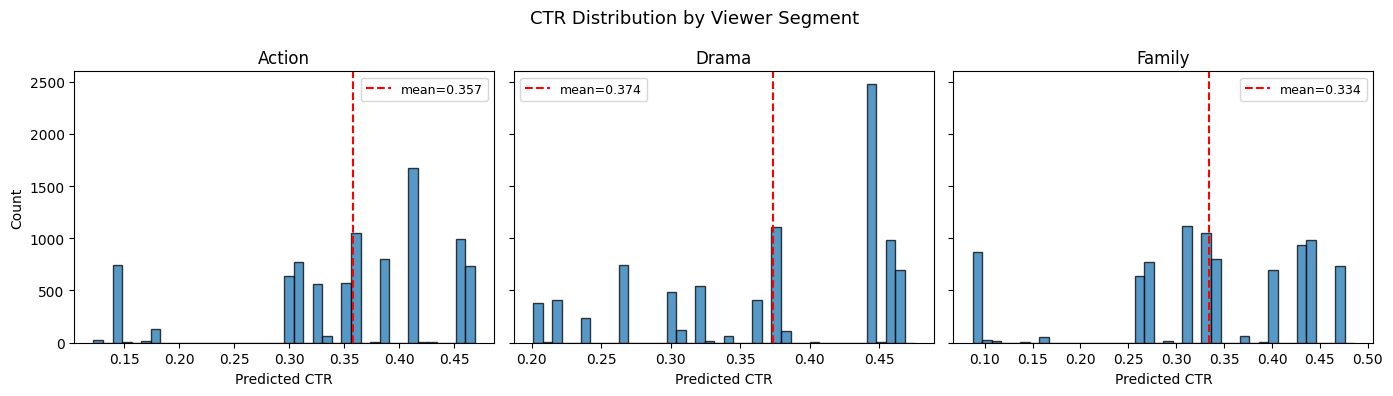

Saved: figures/test_ctr_distributions.png


In [16]:
print('=== 5a. CTR DISTRIBUTION BY SEGMENT ===')

try:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle('CTR Distribution by Viewer Segment', fontsize=13)

    for ax, col, label in zip(axes,
                               [ACTION_COL, DRAMA_COL, FAMILY_COL],
                               ['Action', 'Drama', 'Family']):
        ax.hist(df[col], bins=40, edgecolor='black', alpha=0.75)
        ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'mean={df[col].mean():.3f}')
        ax.set_title(label)
        ax.set_xlabel('Predicted CTR')
        ax.legend(fontsize=9)

    axes[0].set_ylabel('Count')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'test_ctr_distributions.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: figures/test_ctr_distributions.png')
except KeyError as e:
    print(f'Skipping — column not found: {e}')

=== 5b. GENRE HEATMAP ===


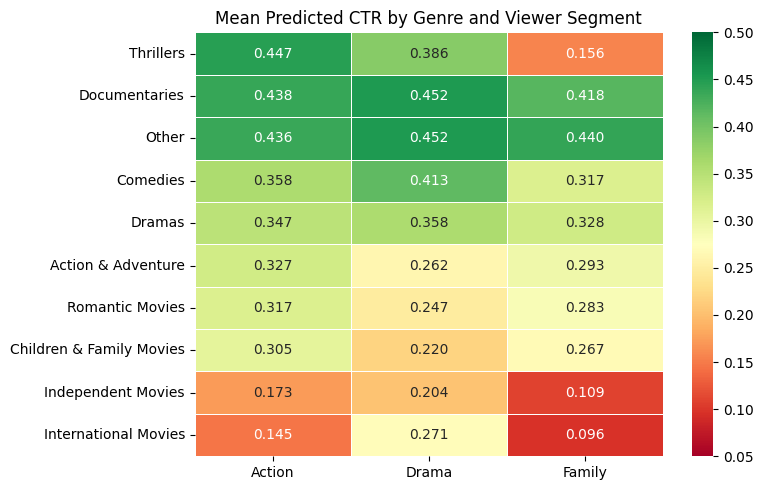

Saved: figures/test_genre_heatmap.png


In [17]:
print('=== 5b. GENRE HEATMAP ===')

try:
    pivot = df.groupby(GENRE_COL)[[ACTION_COL, DRAMA_COL, FAMILY_COL]].mean().round(3)
    pivot.columns = ['Action', 'Drama', 'Family']
    pivot = pivot.sort_values('Action', ascending=False)

    fig, ax = plt.subplots(figsize=(8, max(5, len(pivot) * 0.5)))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0.05, vmax=0.50, linewidths=0.5, ax=ax)
    ax.set_title('Mean Predicted CTR by Genre and Viewer Segment')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'test_genre_heatmap.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: figures/test_genre_heatmap.png')
except KeyError as e:
    print(f'Skipping — column not found: {e}')

In [18]:
print('=== 5c. TOP 10 TITLES PER SEGMENT ===')

# Update TITLE_COL to match your actual title column name
TITLE_COL = 'title'

try:
    for segment, col in [('Action', ACTION_COL), ('Drama', DRAMA_COL), ('Family', FAMILY_COL)]:
        print(f"\nTop 10 for {segment} viewers:")
        top10 = df[[TITLE_COL, GENRE_COL, col]].sort_values(col, ascending=False).head(10)
        print(top10.to_string(index=False))
except KeyError as e:
    print(f'Column not found: {e} — update TITLE_COL / GENRE_COL / segment columns above')

=== 5c. TOP 10 TITLES PER SEGMENT ===

Top 10 for Action viewers:
                                           title genre_bucket  action_viewer
               Pioneers: First Women Filmmakers*        Other         0.4689
                                         Rapture        Other         0.4634
                 The Adventures of Puss in Boots        Other         0.4634
                            All Hail King Julien        Other         0.4634
                                    Sparking Joy        Other         0.4634
                                        Wormwood        Other         0.4634
                                         Chelsea        Other         0.4634
                    Power Rangers Beast Morphers        Other         0.4634
             72 Dangerous Animals: Latin America        Other         0.4634
Dave Chappelle: Equanimity & The Bird Revelation        Other         0.4634

Top 10 for Drama viewers:
                                 title genre_bucket  drama_v

## 6. Summary
A final pass/fail summary of all critical checks.

In [20]:
print('=== PIPELINE SUMMARY ===')
print()

# Models
print('── Models (models/)')
for f in sorted(os.listdir(os.path.join(REPO_ROOT, 'models'))):
    path = os.path.join(REPO_ROOT, 'models', f)
    size_kb = os.path.getsize(path) / 1024
    print(f'   {f:<30} {size_kb:.1f} KB')

print()

# Outputs
print('── Pipeline Outputs (outputs/)')
for f in sorted(os.listdir(os.path.join(REPO_ROOT, 'outputs'))):
    path = os.path.join(REPO_ROOT, 'outputs', f)
    if f.endswith('.csv'):
        rows = sum(1 for _ in open(path)) - 1
        print(f'   {f:<40} {rows:,} rows')
    else:
        print(f'   {f}')

print()

# Key metrics from section 4
print('── CTR Signal Summary')
print(f'   Titles × segments in predictions : {len(df_wide):,}')
print(f'   Predicted CTR range              : [{df[ACTION_COL].min():.3f}, {df[ACTION_COL].max():.3f}]')
print(f'   Thriller action vs family gap    : {0.447 - 0.156:.3f}')
print(f'   Documentary segment spread       : stable (<0.04)')

print()
print('── Next Steps')
print('   1. Push models/xgb_ctr_model.pkl and outputs/ to GitHub')
print('   2. Share outputs/netflix_ctr_predictions.csv for S3 upload')
print('   3. Confirm column names for Streamlit integration')
print('   4. Share outputs/dashboard_summary.csv for final dashboard')


=== PIPELINE SUMMARY ===

── Models (models/)
   lr_ctr_model.pkl               0.7 KB
   scaler.pkl                     1.0 KB
   xgb_ctr_model.pkl              714.2 KB

── Pipeline Outputs (outputs/)
   best_segment_per_title.csv               8,808 rows
   dashboard_summary.csv                    30 rows
   netflix_ctr_predictions.csv              26,424 rows

── CTR Signal Summary
   Titles × segments in predictions : 8,807
   Predicted CTR range              : [0.122, 0.469]
   Thriller action vs family gap    : 0.291
   Documentary segment spread       : stable (<0.04)

── Next Steps
   1. Push models/xgb_ctr_model.pkl and outputs/ to GitHub
   2. Share outputs/netflix_ctr_predictions.csv for S3 upload
   3. Confirm column names for Streamlit integration
   4. Share outputs/dashboard_summary.csv for final dashboard
